In [18]:
import numpy as np
X_test = np.load('/kaggle/input/datasets/minhquang2611/eeg-data/X_test_final.npy')
X_train = np.load('/kaggle/input/datasets/minhquang2611/eeg-data/X_train_final.npy')
y_test = np.load('/kaggle/input/datasets/minhquang2611/eeg-data/y_test_final.npy')
y_train = np.load('/kaggle/input/datasets/minhquang2611/eeg-data/y_train_final.npy')

In [19]:
print(X_test.shape)
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(14694, 64, 129)
(58671, 64, 129)
(58671,)
(14694,)


In [20]:
import torch
import torch.nn as nn

In [21]:
# Assuming your scaled data is 'X_train_scaled' with shape (36765, 64, 97)
# Use .unsqueeze(1) to add that "1" in the second position
X_train_dl = torch.from_numpy(X_train).float().unsqueeze(1)
X_test_dl = torch.from_numpy(X_test).float().unsqueeze(1)
# Convert your labels to a 1D LongTensor
y_train_tensor = torch.from_numpy(y_train).long()
y_test_tensor = torch.from_numpy(y_test).long()

print(y_train_tensor.shape)  # Should show torch.Size([36765])
print(y_train_tensor.dtype)  # Should show torch.int64 (which is Long)
print(X_train_dl.shape)
print(X_test_dl.shape)


torch.Size([58671])
torch.int64
torch.Size([58671, 1, 64, 129])
torch.Size([14694, 1, 64, 129])


In [22]:
import torch
import torch.nn as nn

class EEGNet(nn.Module):
    def __init__(self, num_classes, Chans=64, Samples=129):
        super(EEGNet, self).__init__()

        # F1: Number of temporal filters
        # D: Depth multiplier (spatial filters per temporal filter)
        F1 = 16
        D = 2
        F2 = F1 * D  # 32

        # 1. Temporal Convolution (Frequency Filter)
        # Using kernel 32 (0.2s at 160Hz) provides better "sliding" room for a 0.8s window
        self.conv1 = nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False)
        self.bn1 = nn.BatchNorm2d(F1, momentum=0.01, eps=0.001)

        # 2. Depthwise Convolution (Spatial Filter / "AI CSP")
        # groups=F1 ensures each temporal filter gets its own spatial filter
        self.depthwise_conv = nn.Conv2d(F1, F2, kernel_size=(Chans, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F2, momentum=0.01, eps=0.001)
        self.elu = nn.ELU() # ELU is preferred over ReLU for EEG
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 4), stride=(1, 4))
        self.dropout2 = nn.Dropout(p=0.4)

        # 3. Separable Convolution (Temporal refinement)
        self.separable_conv = nn.Conv2d(F2, F2, kernel_size=(1, 15), padding=(0, 7), groups=F2, bias=False)
        self.bn3 = nn.BatchNorm2d(F2, momentum=0.01, eps=0.001)
        self.pool3 = nn.AvgPool2d(kernel_size=(1, 8), stride=(1, 8))
        self.dropout3 = nn.Dropout(p=0.4)

        # 4. Fully Connected Layer
        # Math: 32 filters * 4 remaining timepoints = 128
        self.fc1 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Layer 1: Temporal
        x = self.bn1(self.conv1(x))

        # Layer 2: Spatial
        x = self.elu(self.bn2(self.depthwise_conv(x)))
        x = self.pool2(x)
        x = self.dropout2(x)

        # Layer 3: Separable
        x = self.elu(self.bn3(self.separable_conv(x)))
        x = self.pool3(x)
        x = self.dropout3(x)

        # Flatten and Classify
        x = x.view(x.size(0), -1) # Flattening to (Batch, 128)
        return self.fc1(x)

In [23]:
# Set your batch size (64 is a good balance for Colab's T4 GPU)
batch_size = 128

In [24]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize and move the model
num_classes = 3
model = EEGNet(num_classes=num_classes).to(device)


Using device: cuda


In [25]:
from torch.utils.data import random_split, DataLoader, TensorDataset

# 1. Create the full dataset
full_dataset = TensorDataset(X_train_dl, y_train_tensor)

# 2. Split into Train (90%) and Validation (10%)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

# 4. Define Weighted Loss to fix "Rest" bias
#class_weights = torch.tensor([1.0, 2.0, 2.2]).to(device)
class_weights = torch.tensor([0.66, 1.30, 1.38]).to(device)

In [26]:
# Replace your old criterion with this:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
# criterion = FocalLoss(weight=class_weights, gamma=2.0)

# Create the optimizer as before
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Add the scheduler
# 'min' mode means it waits for the loss to stop decreasing
# 'patience' is how many epochs to wait before cutting the LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=15)

In [27]:
epochs = 150 # Increased epochs because the scheduler will keep training productive for longer
best_val_acc = 0.0
for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        # Add noise
        noise = torch.randn_like(inputs) * 0.01 
        inputs = inputs + noise
        # Randomly zero out 2 channels out of 64
        if model.training:
          mask = torch.ones(64).to(device)
          mask[torch.randint(0, 64, (2,))] = 0
          inputs = inputs * mask.view(1, 1, 64, 1)

        optimizer.zero_grad()
        outputs = model(inputs) # Math: 128 inputs to the FC layer
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Still using the weighted loss
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct /  val_total

    # IMPORTANT: The scheduler looks at the validation loss to decide when to drop the LR
    scheduler.step(avg_val_loss)
    # MANUALLY GET THE CURRENT LEARNING RATE
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:02d} | LR: {current_lr:.10f} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    # --- ADD THIS AT THE BOTTOM OF YOUR EPOCH LOOP ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # This saves the 'brain' (weights) to a file named best_model.pth
        torch.save(model.state_dict(), 'best_eegnet_model.pth')
        print(f"✨ New Best Model Saved! Accuracy: {best_val_acc:.2f}%")
    # Save every 10 epochs as a recovery point
    if (epoch + 1) % 10 == 0:
      torch.save({
          'epoch': epoch,
          'model_state_dict': model.state_dict(),
          'optimizer_state_dict': optimizer.state_dict(),
          'val_acc': val_acc,
      }, f'checkpoint_epoch_{epoch+1}.pth')

Epoch 01 | LR: 0.0010000000 | Train Loss: 1.0809 | Val Loss: 1.0444 | Val Acc: 37.93%
✨ New Best Model Saved! Accuracy: 37.93%
Epoch 02 | LR: 0.0010000000 | Train Loss: 1.0318 | Val Loss: 0.9830 | Val Acc: 48.45%
✨ New Best Model Saved! Accuracy: 48.45%
Epoch 03 | LR: 0.0010000000 | Train Loss: 1.0087 | Val Loss: 0.9633 | Val Acc: 50.68%
✨ New Best Model Saved! Accuracy: 50.68%
Epoch 04 | LR: 0.0010000000 | Train Loss: 0.9931 | Val Loss: 0.9448 | Val Acc: 52.25%
✨ New Best Model Saved! Accuracy: 52.25%
Epoch 05 | LR: 0.0010000000 | Train Loss: 0.9813 | Val Loss: 0.9315 | Val Acc: 54.11%
✨ New Best Model Saved! Accuracy: 54.11%
Epoch 06 | LR: 0.0010000000 | Train Loss: 0.9691 | Val Loss: 0.9133 | Val Acc: 54.91%
✨ New Best Model Saved! Accuracy: 54.91%
Epoch 07 | LR: 0.0010000000 | Train Loss: 0.9637 | Val Loss: 0.9092 | Val Acc: 56.05%
✨ New Best Model Saved! Accuracy: 56.05%
Epoch 08 | LR: 0.0010000000 | Train Loss: 0.9576 | Val Loss: 0.9025 | Val Acc: 56.53%
✨ New Best Model Saved! A

In [28]:
# Wrap your test data
test_dataset = TensorDataset(X_test_dl, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [29]:
# --- RUN THIS AFTER TRAINING IS TOTALLY FINISHED ---
model.load_state_dict(torch.load('best_eegnet_model.pth'))
model.to(device)
print("✅ Best weights reloaded. Ready for testing!")

✅ Best weights reloaded. Ready for testing!


In [30]:
model.eval()  # Set model to evaluation mode
correct = 0
total = 0

# No gradients needed for testing
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # Get predictions
        outputs = model(inputs)

        # The class with the highest energy is our prediction
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Final Accuracy on the {total} test samples: {accuracy:.2f}%')

Final Accuracy on the 14694 test samples: 53.05%


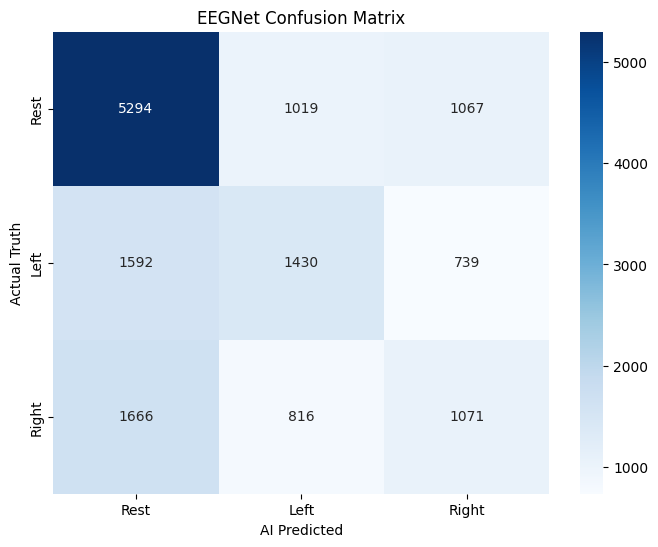

              precision    recall  f1-score   support

        Rest       0.62      0.72      0.66      7380
        Left       0.44      0.38      0.41      3761
       Right       0.37      0.30      0.33      3553

    accuracy                           0.53     14694
   macro avg       0.48      0.47      0.47     14694
weighted avg       0.51      0.53      0.52     14694



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Gather all predictions from the test set
all_preds = []
all_labels = []

model.eval() # Important: turn off dropout
with torch.no_grad(): # Important: save memory
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1) # Get the index of the highest score

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Generate the Matrix
# Assuming 0: Rest, 1: Left, 2: Right (check your label encoding!)
class_names = ['Rest', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

# 3. Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('AI Predicted')
plt.ylabel('Actual Truth')
plt.title('EEGNet Confusion Matrix')
plt.show()

# 4. Print detailed stats
print(classification_report(all_labels, all_preds, target_names=class_names))

In [36]:
!pip install onnx
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 19.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 13.6 MB/s eta 0:00:00


In [49]:
model.eval()
model.cpu()

example_inputs = (torch.randn(1, 1, 64, 129),)

torch.onnx.export(
    model,
    example_inputs,
    "eegnet_model.onnx",
    export_params=True,
    opset_version=14,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},   # make batch dimension dynamic
        'output': {0: 'batch_size'}   # same for output
    }
)

print("Export successful!")

# Verify
import onnx
onnx_model = onnx.load("eegnet_model.onnx")
onnx.checker.check_model(onnx_model)
print("Model is valid!")

/tmp/ipykernel_55/3469294764.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0301 19:40:22.681000 55 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EEGNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EEGNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
Export successful!
Model is valid!


In [50]:
model.to(device)  # move back after export

EEGNet(
  (conv1): Conv2d(1, 16, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
  (bn1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  (depthwise_conv): Conv2d(16, 32, kernel_size=(64, 1), stride=(1, 1), groups=16, bias=False)
  (bn2): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  (elu): ELU(alpha=1.0)
  (pool2): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (dropout2): Dropout(p=0.4, inplace=False)
  (separable_conv): Conv2d(32, 32, kernel_size=(1, 15), stride=(1, 1), padding=(0, 7), groups=32, bias=False)
  (bn3): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
  (pool3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (dropout3): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=128, out_features=3, bias=True)
)

In [41]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 75.0 MB/s eta 0:00:00:00:0100:01


In [42]:
import onnxruntime as ort
import numpy as np

# Load the ONNX model for inference
session = ort.InferenceSession("eegnet_model.onnx")

# Prepare input - must be numpy, not torch tensor
sample = np.random.randn(1, 1, 64, 129).astype(np.float32)

# Run inference
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: sample})

predicted_class = np.argmax(outputs[0])
print(predicted_class)  # 0=Rest, 1=Left, 2=Right

0


In [46]:
import onnxruntime as ort
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import torch



In [51]:
# ============================================
# 1. PYTORCH MODEL PREDICTIONS
# ============================================
model.eval()
model.to(device)

all_preds_torch = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        out = model(X)  # no dann=False
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_torch.extend(preds)
        all_labels.extend(y.numpy())

# ============================================
# 2. ONNX MODEL PREDICTIONS
# ============================================
session = ort.InferenceSession("eegnet_model.onnx")
input_name = session.get_inputs()[0].name

all_preds_onnx = []

for X, y in test_loader:
    X_np = X.numpy().astype(np.float32)
    output = session.run(None, {input_name: X_np})
    preds = np.argmax(output[0], axis=1)
    all_preds_onnx.extend(preds)

# ============================================
# 3. COMPARE
# ============================================
all_labels = np.array(all_labels)
all_preds_torch = np.array(all_preds_torch)
all_preds_onnx = np.array(all_preds_onnx)

print("PYTORCH ACCURACY:", accuracy_score(all_labels, all_preds_torch))
print("ONNX ACCURACY:   ", accuracy_score(all_labels, all_preds_onnx))

print("\n--- PyTorch Report ---")
print(classification_report(all_labels, all_preds_torch,
      target_names=['Rest', 'Left', 'Right']))

print("\n--- ONNX Report ---")
print(classification_report(all_labels, all_preds_onnx,
      target_names=['Rest', 'Left', 'Right']))

mismatch = np.sum(all_preds_torch != all_preds_onnx)
print(f"Prediction mismatches: {mismatch} / {len(all_labels)}")
print(f"Match rate: {100 * (1 - mismatch/len(all_labels)):.2f}%")

2026-03-01 19:40:35.608866972 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:35.709603639 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:35.756776828 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:35.805623719 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:35.852563249 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:35.899809513 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expect

PYTORCH ACCURACY: 0.5304886348169321
ONNX ACCURACY:    0.5304886348169321

--- PyTorch Report ---
              precision    recall  f1-score   support

        Rest       0.62      0.72      0.66      7380
        Left       0.44      0.38      0.41      3761
       Right       0.37      0.30      0.33      3553

    accuracy                           0.53     14694
   macro avg       0.48      0.47      0.47     14694
weighted avg       0.51      0.53      0.52     14694


--- ONNX Report ---
              precision    recall  f1-score   support

        Rest       0.62      0.72      0.66      7380
        Left       0.44      0.38      0.41      3761
       Right       0.37      0.30      0.33      3553

    accuracy                           0.53     14694
   macro avg       0.48      0.47      0.47     14694
weighted avg       0.51      0.53      0.52     14694

Prediction mismatches: 0 / 14694
Match rate: 100.00%


2026-03-01 19:40:41.059234843 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {128,3} for output output
2026-03-01 19:40:41.110377424 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1,3} does not match actual shape of {102,3} for output output


In [53]:
import os
print(os.listdir('/kaggle/working/'))

['checkpoint_epoch_40.pth', 'checkpoint_epoch_100.pth', 'checkpoint_epoch_90.pth', 'checkpoint_epoch_110.pth', 'checkpoint_epoch_20.pth', 'checkpoint_epoch_140.pth', 'checkpoint_epoch_10.pth', 'checkpoint_epoch_30.pth', 'best_eegnet_model.pth', '.virtual_documents', 'checkpoint_epoch_60.pth', 'checkpoint_epoch_50.pth', 'eegnet_model.onnx.data', 'checkpoint_epoch_130.pth', 'eegnet_model.onnx', 'checkpoint_epoch_80.pth', 'checkpoint_epoch_150.pth', 'checkpoint_epoch_120.pth', 'checkpoint_epoch_70.pth']
